## MCPL

In [48]:
import sys
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser')
from torchvision import transforms
from edit_modules.clip import CLIPTextModel
from edit_modules.embed_manager import EmbeddingManager,Embed_control_manager
from diffusers.models.modeling_utils import load_state_dict
from torchvision import transforms as tfms
from PIL import Image
from transformers import CLIPTokenizer
import torch
import os


from diffusers import StableDiffusionCausalControlNetPipeline, Causal_ControlNetModel, UniPCMultistepScheduler,StableDiffusionPipeline,DDIMScheduler
from causal_modules import ddim_modules
size = 256

image_transforms = transforms.Compose(
        [
            transforms.CenterCrop(150),
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ]
        )
original_transforms = transforms.Compose(
        [
            transforms.CenterCrop(150),
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
        ]
        )

conditioning_image_transforms = transforms.Compose(
            [
                transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
                transforms.ToTensor(),
                #transforms.Normalize([0.5], [0.5]),
            ]
        )
        

In [49]:
def load_mcpl_embeddings(base_model_path,tokenizer,embedding_path=None,presudo_token_ids=None,embed_control=True):
    text_encoder = CLIPTextModel.from_pretrained(
        base_model_path, subfolder="text_encoder"
    )
    if embedding_path is not None:
        state_dict = load_state_dict(embedding_path)
        embeddings = []
        tokens = []
        for key,embed in state_dict.items():
            tokens.append(key)
            embeddings.append(embed)
        token_ids = tokenizer.encode(tokens, add_special_tokens=False)
        # 7.4 Load token and embedding
        for token_id, embedding in zip(token_ids, embeddings):
            # add tokens and get ids
            # tokenizer.add_tokens(token)
            # token_id = tokenizer.convert_tokens_to_ids(token)
            text_encoder.get_input_embeddings().weight.data[token_id] = embedding
            print(f"Loaded textual inversion embedding for {token_id}.")


        embed_proj_path  = embedding_path.replace("learned_embeds", "embeds_proj")
            
        if os.path.exists(embed_proj_path):
            embedding_manager = EmbeddingManager(token_ids)
            text_encoder.text_model.embeddings.set_embedding_manager(embedding_manager)
            linear_state_dict = load_state_dict(embed_proj_path)
            embedding_manager.embed_proj.load_state_dict(linear_state_dict)
            embedding_manager.eval()
            print('extend projection')

    

    text_encoder.eval()
    return text_encoder


def change_mcpl_embeddings(new_text_encoder,tokenizer,embedding_path=None,new_presudo_words=None,edit_token_id=None):
    
    if embedding_path is not None:
        state_dict = load_state_dict(embedding_path)
        embeddings = []
        tokens = []
        for key,embed in state_dict.items():
            tokens.append(key)
            embeddings.append(embed)
        token_ids = tokenizer.encode(tokens[1], add_special_tokens=False)
        # 7.4 Load token and embedding
        for token_id, embedding in zip(token_ids, embeddings):
            # add tokens and get ids
            # tokenizer.add_tokens(token)
            # token_id = tokenizer.convert_tokens_to_ids(token)
            
            print(f"Loaded textual inversion embedding for {token_id}.")
            new_text_encoder.get_input_embeddings().weight.data[token_id] = embedding
            

    new_text_encoder.eval()
    return new_text_encoder
            


In [50]:
'''Load pipeline'''


base_model_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce"


mcpl_embedding_path = "../logs/logs_celeA_data500/2025-05-23T10-57-39-mcpl-one-r2/learned_embeds-steps-6000.safetensors"
#mcpl_embedding_path = "../logs/logs_pendulum_data100/2025-05-20T17-39-52-mcpl-one-r2/learned_embeds-steps-6000.safetensors"


# Load mcpl embedding
#prompt = "a human is young and female and beard and hair"
prompt = 'a human is young and male and beard and hair'
#prompt = '@ * & !'
#presudo_words= 'old,male,beard,bald'
presudo_words = 'young,male,beard,hair'
presudo_list = presudo_words.split(',')
tokenizer = CLIPTokenizer.from_pretrained(base_model_path,subfolder="tokenizer")
presudo_token_ids = tokenizer.encode(' '.join(presudo_list), add_special_tokens=False)
embed_control_manager_bool = True

#text_encoder = load_mcpl_embeddings(base_model_path,tokenizer,mcpl_embedding_path,presudo_token_ids,embed_control=embed_control_manager_bool)
text_encoder = CLIPTextModel.from_pretrained(
        base_model_path, subfolder="text_encoder"
)
pipe = StableDiffusionPipeline.from_pretrained(
    base_model_path,text_encoder=text_encoder ,torch_dtype=torch.float32
)
# pipe.scheduler = UniPCMultistepScheduler.from_config(
#     pipe.scheduler.config
# )
pipe.scheduler = DDIMScheduler.from_config(
    pipe.scheduler.config
)
pipe.safety_checker = None
pipe.requires_safety_checker = False
device = torch.device("cuda")
pipe = pipe.to(device)



/home/jovyan/fcvm-data-volume/kzzr229/miniconda3/envs/mcpl/lib/python3.8/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f

  0%|          | 0/50 [00:00<?, ?it/s]

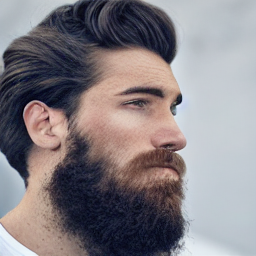

In [51]:
generator = torch.manual_seed(torch.randint(0, 10000, (1,)).item())
new_prompt = 'a human is young and female and beard and hair'
recons_image = pipe(
    prompt, num_inference_steps=50,height=256,width=256,guidance_scale=5.0,negative_prompt=None,num_images_per_prompt=2
).images
recons_image[0]

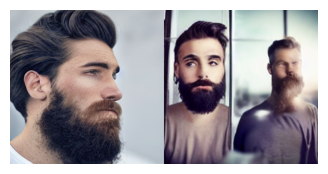

In [52]:
ddim_modules.save_images_grid([recons_image],(1,len(recons_image)),None)

In [103]:
'''Load pipeline'''
from copy import deepcopy


new_mcpl_embedding_path = "../logs/logs_celeA_data500/2025-05-23T08-55-50-mcpl-one-r2-addition/learned_embeds-steps-6000.safetensors"
#new_mcpl_embedding_path = "../logs/logs_celeA_data500/2025-05-28T09-57-37-mcpl-one-r2/learned_embeds-steps-6000.safetensors"
#new_mcpl_embedding_path = "../logs/logs_celeA_data500/2025-05-23T09-51-13-mcpl-one-r2/learned_embeds-steps-6000.safetensors"
edit_token_id = 3

new_text_encoder = deepcopy(text_encoder)
new_text_encoder = change_mcpl_embeddings(new_text_encoder,tokenizer,new_mcpl_embedding_path,presudo_token_ids[edit_token_id])

new_pipe = StableDiffusionPipeline.from_pretrained(
    base_model_path,text_encoder=new_text_encoder ,torch_dtype=torch.float32
)
# new_pipe.scheduler = UniPCMultistepScheduler.from_config(
#     new_pipe.scheduler.config
# )
pipe.scheduler = DDIMScheduler.from_config(
    pipe.scheduler.config
)
new_pipe.safety_checker = None
new_pipe.requires_safety_checker = False

new_pipe = new_pipe.to(device)



Loaded textual inversion embedding for 9052.
Loaded textual inversion embedding for 34308.
Loaded textual inversion embedding for 342.
Loaded textual inversion embedding for 285.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/50 [00:00<?, ?it/s]

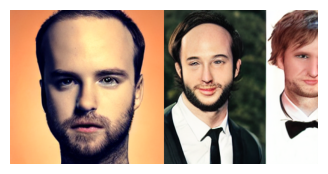

In [93]:
generator = torch.manual_seed(torch.randint(0, 10000, (1,)).item())
recons_image = new_pipe(
    prompt, num_inference_steps=50,height=256,width=256,guidance_scale=5.0,negative_prompt=None,num_images_per_prompt=2
).images
ddim_modules.save_images_grid([recons_image],(1,len(recons_image)),None)

In [86]:
from tqdm import tqdm
# Sample function (regular DDIM)
@torch.no_grad()
def sample(
    pipe,
    prompt,
    start_step=0,
    start_latents=None,
    guidance_scale=3.5,
    num_inference_steps=30,
    num_images_per_prompt=1,
    negative_prompt="",
    device=device,
    controlnet_image=None,
    intervention_indx=None,
    intervention_values=None,
    label=None,
    return_PIL = True,
    
):
    if start_latents is None:
        start_latents = torch.randn(1, 4, 32, 32, device=device)
        start_latents *= pipe.scheduler.init_noise_sigma
    if guidance_scale>1:
        do_classifier_free_guidance = True
    else:
        do_classifier_free_guidance= False    

    start_latents, prompt, label = ddim_modules.align_batch_size(start_latents, prompt, label)
    
    _,negtive_prompt_embedding = pipe.encode_prompt(
        prompt, device, num_images_per_prompt, do_classifier_free_guidance, negative_prompt
    )
    input_ids = pipe.tokenizer(prompt,
                        padding="max_length",
                        truncation=True,
                        max_length=pipe.tokenizer.model_max_length,
                        return_tensors="pt",
                    ).input_ids.to(device)
    if input_ids.dim() ==1:
        input_ids=input_ids.unsqueeze(0)


    pipe.scheduler.set_timesteps(num_inference_steps, device=device)

    # Create a random starting point if we don't have one already
    
    
    start_latents, label = start_latents.to(device),label.to(device)

    latents = start_latents.clone()
    
    for i in tqdm(range(start_step, num_inference_steps)):

        t = pipe.scheduler.timesteps[i]

        # Expand the latents if we are doing classifier free guidance
        latent_model_input = torch.cat([latents] * 2) if do_classifier_free_guidance else latents
        latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)

    
        encoder_hidden_states = pipe.text_encoder(input_ids)[0].to(dtype=latent_model_input.dtype)
        if do_classifier_free_guidance:
            if negtive_prompt_embedding is not None:
                encoder_hidden_states = torch.cat([negtive_prompt_embedding, encoder_hidden_states])
            else:
                assert encoder_hidden_states is not None, 'negative_prompt_embedding should be provided when do_classifier_free_guidance is True'



        # Predict the noise residual
        noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=encoder_hidden_states,
                    return_dict=False)[0]

        # Perform guidance
        if do_classifier_free_guidance:
            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

        # Normally we'd rely on the scheduler to handle the update step:
        # latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample
        #latents = pipe.scheduler.step(noise_pred, t, latents, return_dict=False)[0]
        # Instead, let's do it ourselves:
        prev_t = max(1, t.item() - (1000 // num_inference_steps))  # t-1
        alpha_t = pipe.scheduler.alphas_cumprod[t.item()]
        alpha_t_prev = pipe.scheduler.alphas_cumprod[prev_t]
        predicted_x0 = (latents - (1 - alpha_t).sqrt() * noise_pred) / alpha_t.sqrt()
        direction_pointing_to_xt = (1 - alpha_t_prev).sqrt() * noise_pred
        latents = alpha_t_prev.sqrt() * predicted_x0 + direction_pointing_to_xt

    # Post-processing
    images = pipe.vae.decode(latents/ pipe.vae.config.scaling_factor,return_dict=False)[0]
    if return_PIL:
        do_denormalize = [True] * images.shape[0]
        output = pipe.image_processor.postprocess(images,do_denormalize=do_denormalize)
    else:
        output = images
    return output

## Inversion
@torch.no_grad()
def invert(
    pipe,
    start_latents,
    prompt,
    guidance_scale=1,
    num_inference_steps=80,
    num_images_per_prompt=1,
    negative_prompt="",
    device=device,
    controlnet_image=None,
    intervention_indx=None,
    intervention_values=None,
    label=None,
):    
    if guidance_scale>1:
        do_classifier_free_guidance = True
    else:
        do_classifier_free_guidance= False    
    if start_latents is None:
        start_latents = torch.randn(1, 4, 32, 32, device=device)
        start_latents *= pipe.scheduler.init_noise_sigma
    # # Encode prompt
    start_latents, prompt, label = ddim_modules.align_batch_size(start_latents, prompt, label)
    
    _,negtive_prompt_embedding = pipe.encode_prompt(
        prompt, device, num_images_per_prompt, do_classifier_free_guidance, negative_prompt
    )
    input_ids = pipe.tokenizer(prompt,
                        padding="max_length",
                        truncation=True,
                        max_length=pipe.tokenizer.model_max_length,
                        return_tensors="pt",
                    ).input_ids.to(device)
    if input_ids.dim() ==1:
        input_ids=input_ids.unsqueeze(0)
    
    
    # Create a random starting point if we don't have one already
    
    # Latents are now the specified start latents
    start_latents, label = start_latents.to(device),label.to(device)
    latents = start_latents.clone()

    # We'll keep a list of the inverted latents as the process goes on
    intermediate_latents = []

    # Set num inference steps
    pipe.scheduler.set_timesteps(num_inference_steps, device=device)

    # Reversed timesteps <<<<<<<<<<<<<<<<<<<<
    timesteps = reversed(pipe.scheduler.timesteps)
    for i in tqdm(range(1, num_inference_steps), total=num_inference_steps - 1):

        # We'll skip the final iteration
        if i >= num_inference_steps - 1:
            continue

        t = timesteps[i]

        # Expand the latents if we are doing classifier free guidance
        latent_model_input = torch.cat([latents] * 2) if do_classifier_free_guidance else latents
        latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)

    
        encoder_hidden_states = pipe.text_encoder(input_ids)[0].to(dtype=latent_model_input.dtype)
        if do_classifier_free_guidance:
            if negtive_prompt_embedding is not None:
                encoder_hidden_states = torch.cat([negtive_prompt_embedding, encoder_hidden_states])
            else:
                assert encoder_hidden_states is not None, 'negative_prompt_embedding should be provided when do_classifier_free_guidance is True'

        
        
        # Predict the noise residual
        noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=encoder_hidden_states,
                    return_dict=False)[0]
        #noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=encoder_hidden_states, return_dict=False)[0]
        

        # Perform guidance
        if guidance_scale>1:
            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

        current_t = max(0, t.item() - (1000 // num_inference_steps))  # t
        next_t = t  # min(999, t.item() + (1000//num_inference_steps)) # t+1
        alpha_t = pipe.scheduler.alphas_cumprod[current_t]
        alpha_t_next = pipe.scheduler.alphas_cumprod[next_t]

        # Inverted update step (re-arranging the update step to get x(t) (new latents) as a function of x(t-1) (current latents)
        latents = (latents - (1 - alpha_t).sqrt() * noise_pred) * (alpha_t_next.sqrt() / alpha_t.sqrt()) + (
            1 - alpha_t_next
        ).sqrt() * noise_pred

        # Store
        intermediate_latents.append(latents)

    return torch.stack(intermediate_latents, dim=0)

In [55]:
import random
import pandas as pd
from torchvision.datasets import CelebA
def dataset_load_path(data_root,dataset,split='train'):
    data_dir = data_root
    data = CelebA(root=data_dir, split=split, transform=None, download=False)
    num_images = len(data)
    if 'simple' in dataset:
        selected_item = ['Smiling','Eyeglasses']
    
    elif 'complex' in dataset:
        selected_item = ['Young','Male','No_Beard','Bald']
    else:
        AssertionError('no such {} dataset'.format(dataset))
    attribute_ids = [data.attr_names.index(attr) for attr in selected_item]
    metrics = {attr: torch.as_tensor(data.attr[:, attr_id], dtype=torch.float32) for attr, attr_id in zip(selected_item, attribute_ids)}

    attrs = torch.cat([metrics[attr].unsqueeze(1)
                            for attr in selected_item], dim=1)
    imglabel= attrs
    possible_values = {attr: torch.unique(values, dim=0) for attr, values in metrics.items()}
    
    img_id = random.randint(0,num_images)
    return data,imglabel,num_images

#img_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_data/pendulum/test/a_-1_128_4_12.png'
data,imglabel,num_images = dataset_load_path(data_root='/home/jovyan/fcvm-data-volume/kzzr229/workspace/counterfactual-benchmark/datasets/',dataset='celeA_complex',split='test')

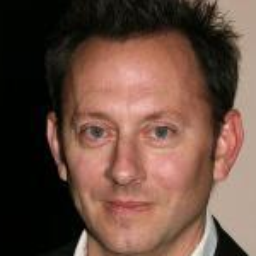

In [104]:
# paper image id (190,34,2,31)
img_id = random.randint(0,num_images)
img_id=190
img,label = data[img_id][0],imglabel[img_id].unsqueeze(0)
image = img
if not image.mode == "RGB":
    image = image.convert("RGB")

original_img = image.copy()
original_img = original_transforms(original_img)
condition_image = image.copy()
image = image_transforms(image).unsqueeze(0)
original_img

In [105]:
generator = torch.manual_seed(torch.randint(0, 10000, (1,)).item())
with torch.no_grad():
    latent = pipe.vae.encode(image.to(device))
    img_latent = 0.18215 * latent.latent_dist.sample()
# Keep inversion guidance scale to 1 will protect the identity
invert_guidance_scale = 1.0
num_steps = 50
inverted_latents = invert(pipe,
        img_latent,
        prompt,
        guidance_scale=invert_guidance_scale,
        num_inference_steps=num_steps,
        num_images_per_prompt=1,
        negative_prompt=None,
        device=device,
        controlnet_image=None,
        intervention_indx=None,
        intervention_values=None,
        label=label.clone())

100%|██████████| 49/49 [00:01<00:00, 25.29it/s]


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:02<00:00, 20.31it/s]


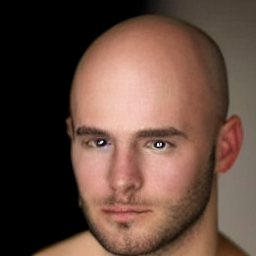

In [108]:
s_step = 0
#new_prompt='a human is young and male and unbeard and hair'
new_prompt = 'a human is young and male and unbeard and bald'
final_im = sample(
        #new_pipe,
        pipe,
        new_prompt,
        start_step=s_step,
        #start_latents=None,
        start_latents=inverted_latents[-(s_step + 1)].clone(),
        guidance_scale=5.5,
        num_inference_steps=num_steps,
        num_images_per_prompt=1,
        negative_prompt=None,
        device=device,
        controlnet_image=None,
        intervention_indx=None,
        intervention_values=None,
        label=label.clone(),
        return_PIL = True,
    )
final_im[0]

# Plot Attn Maps

In [25]:
import os
prompts = [prompt]
out_base = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/outputs/attention_maps/'
exp_name = 'textcond'
if not os.path.exists(out_base):
    os.mkdir(out_base) 
out_path_base = os.path.join(out_base, exp_name)
if not os.path.exists(out_path_base):
    os.mkdir(out_path_base) 
out_path_prompt = os.path.join(out_path_base, prompts[0])
if not os.path.exists(out_path_prompt):
    os.mkdir(out_path_prompt)
out_dir = out_path_prompt
out_name = 'causalnet'+'.png'

ax shape: (1, 7)


100%|██████████| 49/49 [00:01<00:00, 24.78it/s]


  0%|          | 0/50 [00:00<?, ?it/s]

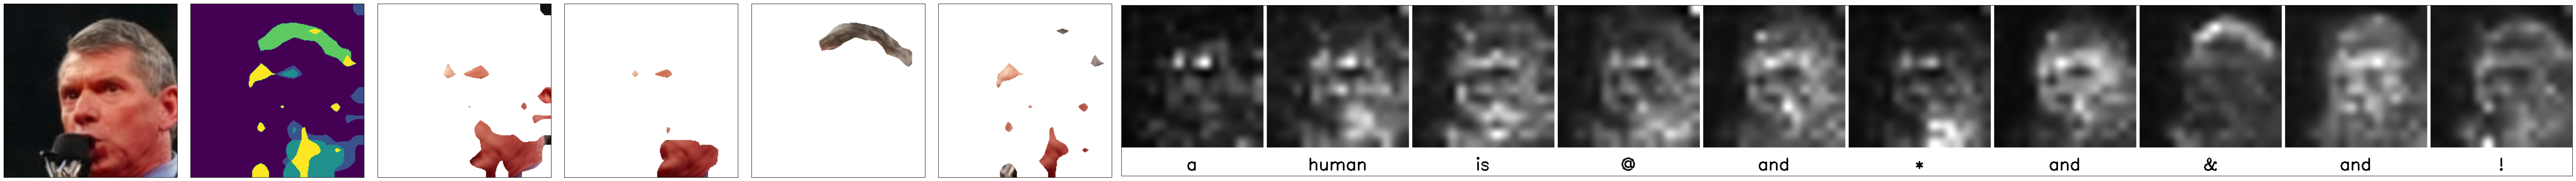

<Figure size 640x480 with 0 Axes>

In [26]:
import sys
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser')
from scripts.show_attn_maps import ptp_tools,ptp_utils
import importlib
importlib.reload(ptp_tools)
importlib.reload(ptp_utils)
attn_threshold = 0.5

# pipe = StableDiffusionCausalControlNetPipeline.from_pretrained(
#     base_model_path, controlnet=controlnet,text_encoder=text_encoder ,torch_dtype=torch.float32
# )
# pipe.scheduler = DDIMScheduler.from_config(
#     pipe.scheduler.config
# )
# pipe.safety_checker = None
# pipe.requires_safety_checker = False
# #pipe.load_mcpl_inversion(mcpl_embedding_path)
generator = torch.manual_seed(0)

# # memory optimization.
# #pipe.enable_model_cpu_offload()
# pipe = pipe.to(device)

overlapped_mask,attn_img = ptp_tools.plot_img_attn_mask_mcpl(pipe, prompts,presudo_words,None, \
        device, out_dir, out_name, latent=image,res=16,label=label, \
        GUIDANCE_SCALE=1.0,attn_threshold=attn_threshold, only_sampling=False,show_text=True,class_select=False,\
        intervention_indx=None,intervention_values=None,from_where=['down','up'],mask_concepts=True, g_gpu=generator,num_steps=50,img_size=size,exp_names=[exp_name],dataset='celeba')